# Data Collection

In [1]:
import pandas as pd
import numpy as np
import requests
import time
from io import StringIO
from plotnine import *

BASE_URL = "https://api.themoviedb.org/3"
API_KEY = "939ed19c3d5487d60bf45c0c8e353499"

url = f"{BASE_URL}/movie/popular"

params = {
    "api_key": API_KEY,
    "page": 1
}

response = requests.get(url, params=params, timeout=30)

print("Status code:", response.status_code)
print("Request URL:", response.url)

Status code: 200
Request URL: https://api.themoviedb.org/3/movie/popular?api_key=939ed19c3d5487d60bf45c0c8e353499&page=1


In [2]:
data = response.json()

print("Top-level keys:", data.keys())
print("Total pages:", data.get("total_pages"))
print("Movies on this page:", len(data.get("results", [])))

pd.DataFrame(data.get("results", [])).head()

Top-level keys: dict_keys(['page', 'results', 'total_pages', 'total_results'])
Total pages: 55693
Movies on this page: 20


,adult,backdrop_path,genre_ids,id,original_language,original_title,overview,popularity,poster_path,release_date,title,video,vote_average,vote_count
0,False,/6yeVcxFR0j08vlv2OlL6zbewm4D.jpg,"[28, 878, 53]",1265609,en,War Machine,On one last grueling mission during Army Range...,554.0951,/tlPgDzwIE7VYYIIAGCTUOnN4wI1.jpg,2026-02-12,War Machine,False,7.238,815
1,False,/u6YE4rlEWOiYoqhPJuNvt5GHxgu.jpg,"[28, 80, 53]",1290821,en,Shelter,A man living in self-imposed exile on a remote...,315.9799,/buPFnHZ3xQy6vZEHxbHgL1Pc6CR.jpg,2026-01-28,Shelter,False,6.613,300
2,False,/hYgUkH7TusddHRtelj53I6gFOWR.jpg,"[28, 53]",799882,en,The Bluff,When her tranquil life on a remote island is s...,209.6292,/w0jwjFmRu2or7LQqh1tSMFjq0At.jpg,2026-02-17,The Bluff,False,6.323,263
3,False,/lgotja3xMoJZbynwHfcQcJAEMWH.jpg,"[16, 35, 12, 10751, 9648]",1084242,en,Zootopia 2,After cracking the biggest case in Zootopia's ...,184.6470,/oJ7g2CifqpStmoYQyaLQgEU32qO.jpg,2025-11-26,Zootopia 2,False,7.609,2170
4,False,/2RrLuIfIzGWWIH8IAEo6o0IYHmx.jpg,"[16, 10751, 878, 35]",1327819,en,Hoppers,Scientists have discovered how to 'hop' human ...,157.4956,/xjtWQ2CL1mpmMNwuU5HeS4Iuwuu.jpg,2026-03-04,Hoppers,False,7.700,188


In [3]:
# Collect movie IDs from multiple pages

MOVIES_COUNT = 200
MOVIES_PER_PAGE = 20
n_pages = int(np.ceil(MOVIES_COUNT / MOVIES_PER_PAGE))

all_movie_ids = []

for page in range(1, n_pages + 1):
    params = {
        "api_key": API_KEY,
        "page": page
    }

    response = requests.get(f"{BASE_URL}/movie/popular", params=params, timeout=30)
    data = response.json()

    movies = data.get("results", [])
    page_ids = [movie["id"] for movie in movies]
    all_movie_ids.extend(page_ids)

    print(f"Page {page}: collected {len(page_ids)} IDs")
    time.sleep(0.15)

all_movie_ids = all_movie_ids[:MOVIES_COUNT]

print("Total collected IDs:", len(all_movie_ids))
print("First 10 IDs:", all_movie_ids[:10])

Page 1: collected 20 IDs
Page 2: collected 20 IDs
Page 3: collected 20 IDs
Page 4: collected 20 IDs
Page 5: collected 20 IDs
Page 6: collected 20 IDs
Page 7: collected 20 IDs
Page 8: collected 20 IDs
Page 9: collected 20 IDs
Page 10: collected 20 IDs
Total collected IDs: 200
First 10 IDs: [1265609, 1290821, 799882, 1084242, 1327819, 840464, 1193501, 1236153, 1523145, 1088434]


In [4]:
detailed_movies = []

for i, mid in enumerate(all_movie_ids):
    detail_url = f"{BASE_URL}/movie/{mid}"
    params = {"api_key": API_KEY}

    response = requests.get(detail_url, params=params, timeout=30)
    detail = response.json()

    movie_info = {
        "movie_id": detail.get("id"),
        "title": detail.get("title"),
        "release_date": detail.get("release_date"),
        "popularity": detail.get("popularity"),
        "vote_average": detail.get("vote_average"),
        "vote_count": detail.get("vote_count"),
        "budget": detail.get("budget"),
        "revenue": detail.get("revenue"),
        "runtime": detail.get("runtime"),
        "genres": detail.get("genres")
    }

    detailed_movies.append(movie_info)

    if (i + 1) % 20 == 0:
        print(f"Fetched details for {i + 1} movies")

    time.sleep(0.2)


df_movies_raw = pd.DataFrame(detailed_movies)
df_movies_raw.head()

Fetched details for 20 movies
Fetched details for 40 movies
Fetched details for 60 movies
Fetched details for 80 movies
Fetched details for 100 movies
Fetched details for 120 movies
Fetched details for 140 movies
Fetched details for 160 movies
Fetched details for 180 movies
Fetched details for 200 movies


,movie_id,title,release_date,popularity,vote_average,vote_count,budget,revenue,runtime,genres
0,1265609,War Machine,2026-02-12,554.0951,7.243,818,0,0,110,"[{'id': 28, 'name': 'Action'}, {'id': 878, 'na..."
1,1290821,Shelter,2026-01-28,315.9799,6.599,302,50000000,42079609,108,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam..."
2,799882,The Bluff,2026-02-17,209.6292,6.314,264,0,0,102,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam..."
3,1084242,Zootopia 2,2025-11-26,184.6470,7.608,2174,150000000,1861044662,108,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '..."
4,1327819,Hoppers,2026-03-04,157.4956,7.730,189,150000000,164700900,105,"[{'id': 16, 'name': 'Animation'}, {'id': 10751..."


# Data Cleaning

In [5]:

# Make a copy so the raw data stays untouched
df_movies = df_movies_raw.copy()

# ----------------------------
# 1. Basic structure check
# ----------------------------
print("Shape:", df_movies.shape)
print("\nColumns:")
print(df_movies.columns.tolist())

print("\nMissing values before cleaning:")
print(df_movies.isna().sum())

# ----------------------------
# 2. Clean release_date
# ----------------------------
df_movies["release_date"] = pd.to_datetime(df_movies["release_date"], errors="coerce")
df_movies["release_year"] = df_movies["release_date"].dt.year

# ----------------------------
# 3. Clean numeric columns
# ----------------------------
numeric_cols = [
    "popularity", "vote_average", "vote_count",
    "budget", "revenue", "runtime"
]

for col in numeric_cols:
    df_movies[col] = pd.to_numeric(df_movies[col], errors="coerce")

# In TMDb, budget/revenue = 0 often means missing or unreported
df_movies["budget"] = df_movies["budget"].replace(0, np.nan)
df_movies["revenue"] = df_movies["revenue"].replace(0, np.nan)

# runtime = 0 is also suspicious, treat as missing if it appears
df_movies["runtime"] = df_movies["runtime"].replace(0, np.nan)

# ----------------------------
# 4. Clean genres
# ----------------------------
# Original format example:
# [{'id': 28, 'name': 'Action'}, {'id': 12, 'name': 'Adventure'}]

def extract_genre_names(genre_list):
    if isinstance(genre_list, list):
        names = [g.get("name") for g in genre_list if isinstance(g, dict) and "name" in g]
        return names
    return []

df_movies["genre_names"] = df_movies["genres"].apply(extract_genre_names)

# Convert list of genre names to a single string for easier display / summary
df_movies["genres_str"] = df_movies["genre_names"].apply(
    lambda x: " | ".join(x) if len(x) > 0 else np.nan
)

# Use the first genre as a simpler categorical variable for boxplots later
df_movies["primary_genre"] = df_movies["genre_names"].apply(
    lambda x: x[0] if len(x) > 0 else np.nan
)

# ----------------------------
# 5. Final check
# ----------------------------
print("\nMissing values after cleaning:")
print(df_movies.isna().sum())

print("\nSummary statistics:")
print(df_movies[[
    "vote_average", "vote_count", "popularity",
    "runtime", "budget", "revenue", "release_year"
]].describe())

print("\nSample cleaned data:")
display(df_movies[[
    "movie_id", "title", "release_date", "release_year",
    "popularity", "vote_average", "vote_count",
    "budget", "revenue", "runtime",
    "genres_str", "primary_genre"
]].head())

Shape: (200, 10)

Columns:
['movie_id', 'title', 'release_date', 'popularity', 'vote_average', 'vote_count', 'budget', 'revenue', 'runtime', 'genres']

Missing values before cleaning:
movie_id        0
title           0
release_date    0
popularity      0
vote_average    0
vote_count      0
budget          0
revenue         0
runtime         0
genres          0
dtype: int64

Missing values after cleaning:
movie_id          0
title             0
release_date      1
popularity        0
vote_average      0
vote_count        0
budget           81
revenue          83
runtime           7
genres            0
release_year      1
genre_names       0
genres_str        0
primary_genre     0
dtype: int64

Summary statistics:
       vote_average    vote_count  popularity     runtime        budget  \
count    200.000000    200.000000  200.000000  193.000000  1.190000e+02   
mean       6.363450   4161.450000   49.826216  114.393782  8.084626e+07   
std        2.014428   9175.753284   51.257485   34.2

,movie_id,title,release_date,release_year,popularity,vote_average,vote_count,budget,revenue,runtime,genres_str,primary_genre
0,1265609,War Machine,2026-02-12,2026.0,554.0951,7.243,818,NaN,NaN,110.0,Action | Science Fiction | Thriller,Action
1,1290821,Shelter,2026-01-28,2026.0,315.9799,6.599,302,50000000.0,4.207961e+07,108.0,Action | Crime | Thriller,Action
2,799882,The Bluff,2026-02-17,2026.0,209.6292,6.314,264,NaN,NaN,102.0,Action | Thriller,Action
3,1084242,Zootopia 2,2025-11-26,2025.0,184.6470,7.608,2174,150000000.0,1.861045e+09,108.0,Animation | Comedy | Adventure | Family | Mystery,Animation
4,1327819,Hoppers,2026-03-04,2026.0,157.4956,7.730,189,150000000.0,1.647009e+08,105.0,Animation | Family | Science Fiction | Comedy,Animation


In [6]:
# ----------------------------
# 7. Create analysis dataset
# ----------------------------
# For rating analysis, exclude movies with no meaningful audience rating
# A small vote threshold helps reduce unstable ratings

VOTE_THRESHOLD = 30

df_analysis = df_movies[
    (df_movies["vote_count"] >= VOTE_THRESHOLD) &
    (df_movies["vote_average"] > 0)
].copy()

print("Original cleaned dataset shape:", df_movies.shape)
print("Analysis dataset shape:", df_analysis.shape)

print("\nRemoved rows:", df_movies.shape[0] - df_analysis.shape[0])

print("\nVote count summary in analysis dataset:")
print(df_analysis["vote_count"].describe())

print("\nVote average summary in analysis dataset:")
print(df_analysis["vote_average"].describe())

# ----------------------------
# 8. Quick categorical summaries
# ----------------------------
print("\nTop 10 primary genres:")
print(df_analysis["primary_genre"].value_counts(dropna=False).head(10))

print("\nRelease year distribution:")
print(df_analysis["release_year"].value_counts().sort_index().tail(15))

Original cleaned dataset shape: (200, 14)
Analysis dataset shape: (152, 14)

Removed rows: 48

Vote count summary in analysis dataset:
count      152.000000
mean      5473.039474
std      10185.429276
min         30.000000
25%        135.250000
50%        601.000000
75%       3224.750000
max      39125.000000
Name: vote_count, dtype: float64

Vote average summary in analysis dataset:
count    152.000000
mean       6.867072
std        1.008412
min        4.160000
25%        6.170000
50%        6.934000
75%        7.669250
max        8.716000
Name: vote_average, dtype: float64

Top 10 primary genres:
primary_genre
Action             45
Horror             19
Drama              19
Adventure          12
Science Fiction    11
Animation          10
Comedy             10
Thriller            9
Mystery             4
Crime               4
Name: count, dtype: int64

Release year distribution:
release_year
2009.0     2
2010.0     3
2012.0     3
2013.0     3
2014.0     2
2016.0     1
2017.0     2
20

# EDA

In [7]:
# Table 1: Summary statistics for the main analysis dataset
main_summary = (
    df_analysis[["vote_average", "popularity", "vote_count", "runtime"]]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

main_summary

,vote_average,popularity,vote_count,runtime
mean,6.87,53.13,5473.04,118.62
median,6.93,33.04,601.00,111.00
min,4.16,17.58,30.00,72.00
max,8.72,554.10,39125.00,224.00


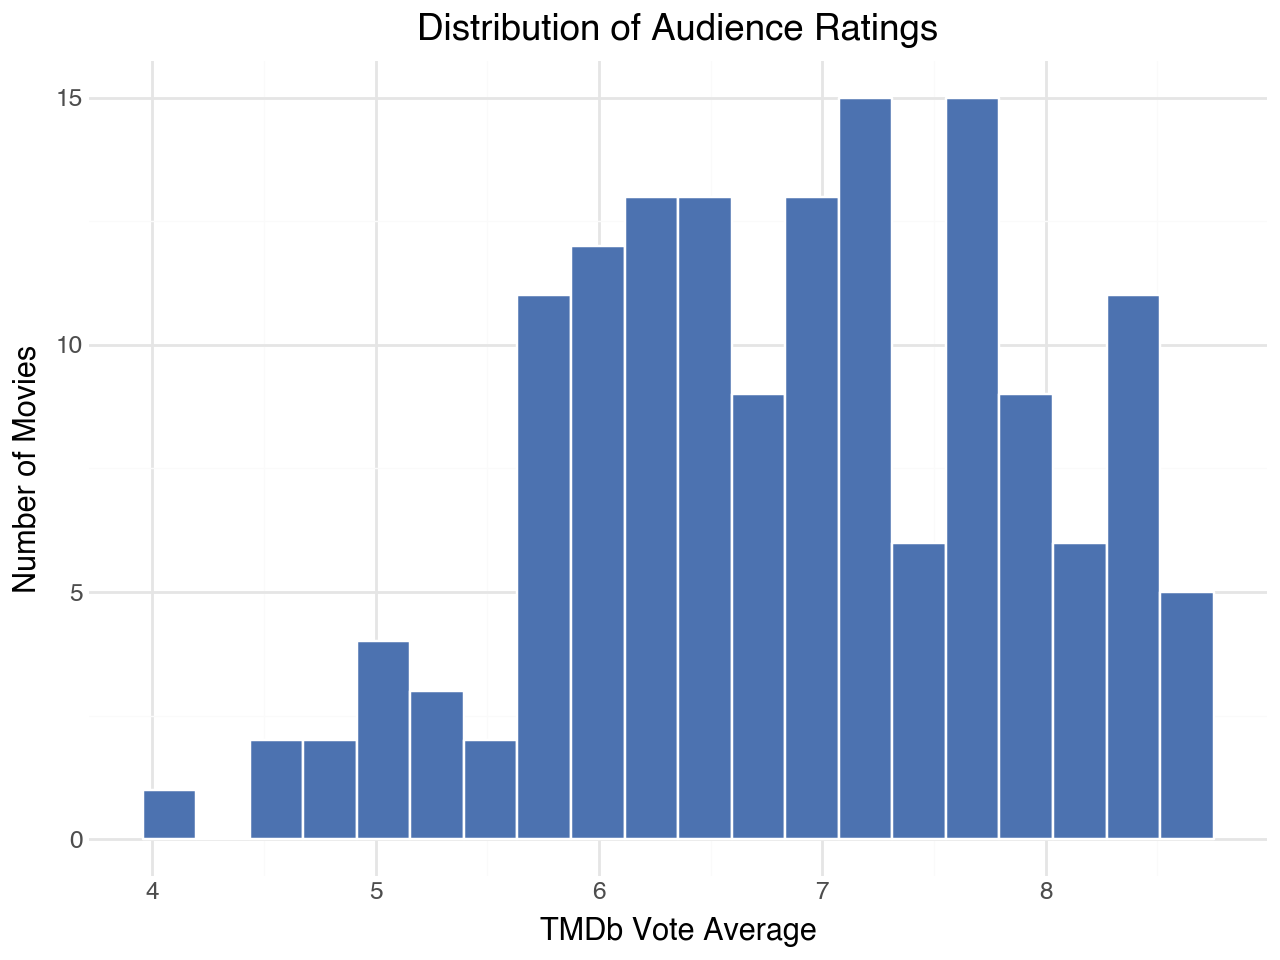

In [8]:
# Rating Distribution
p1 = (
    ggplot(df_analysis, aes(x="vote_average"))
    + geom_histogram(bins=20, fill="#4C72B0", color="white")
    + labs(
        title="Distribution of Audience Ratings",
        x="TMDb Vote Average",
        y="Number of Movies"
    )
    + theme_minimal()
)

p1

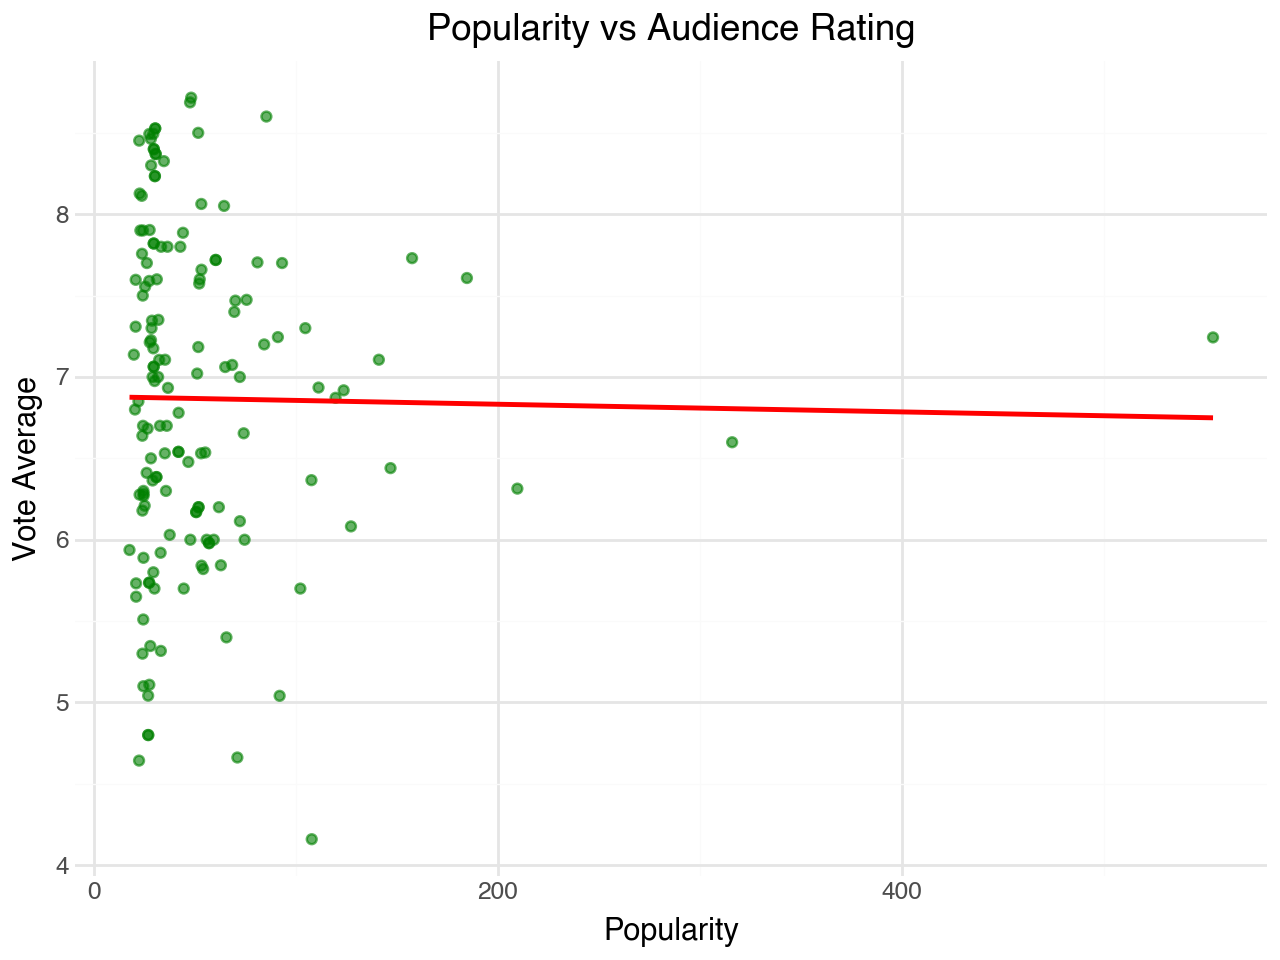

In [9]:
# Popularity and Ratings
p2 = (
    ggplot(df_analysis, aes(x="popularity", y="vote_average"))
    + geom_point(color="green", alpha=0.6)
    + geom_smooth(method="lm", color="red", se=False)
    + labs(
        title="Popularity vs Audience Rating",
        x="Popularity",
        y="Vote Average"
    )
    + theme_minimal()
)

p2

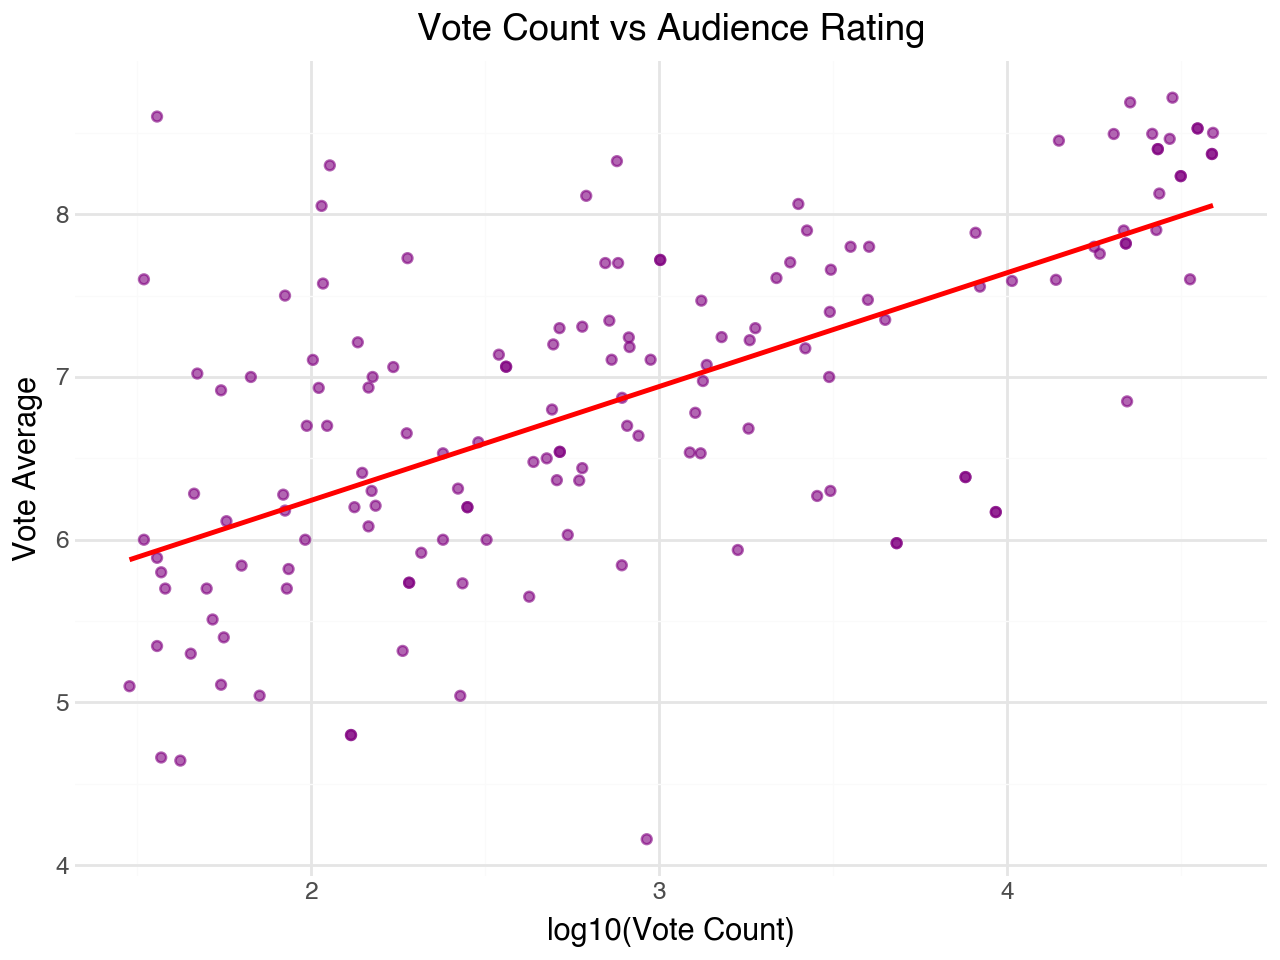

In [10]:
# Vote Counts and Ratings
df_analysis["log_vote_count"] = np.log10(df_analysis["vote_count"])

p3 = (
    ggplot(df_analysis, aes(x="log_vote_count", y="vote_average"))
    + geom_point(color="purple", alpha=0.6)
    + geom_smooth(method="lm", color="red", se=False)
    + labs(
        title="Vote Count vs Audience Rating",
        x="log10(Vote Count)",
        y="Vote Average"
    )
    + theme_minimal()
)

p3

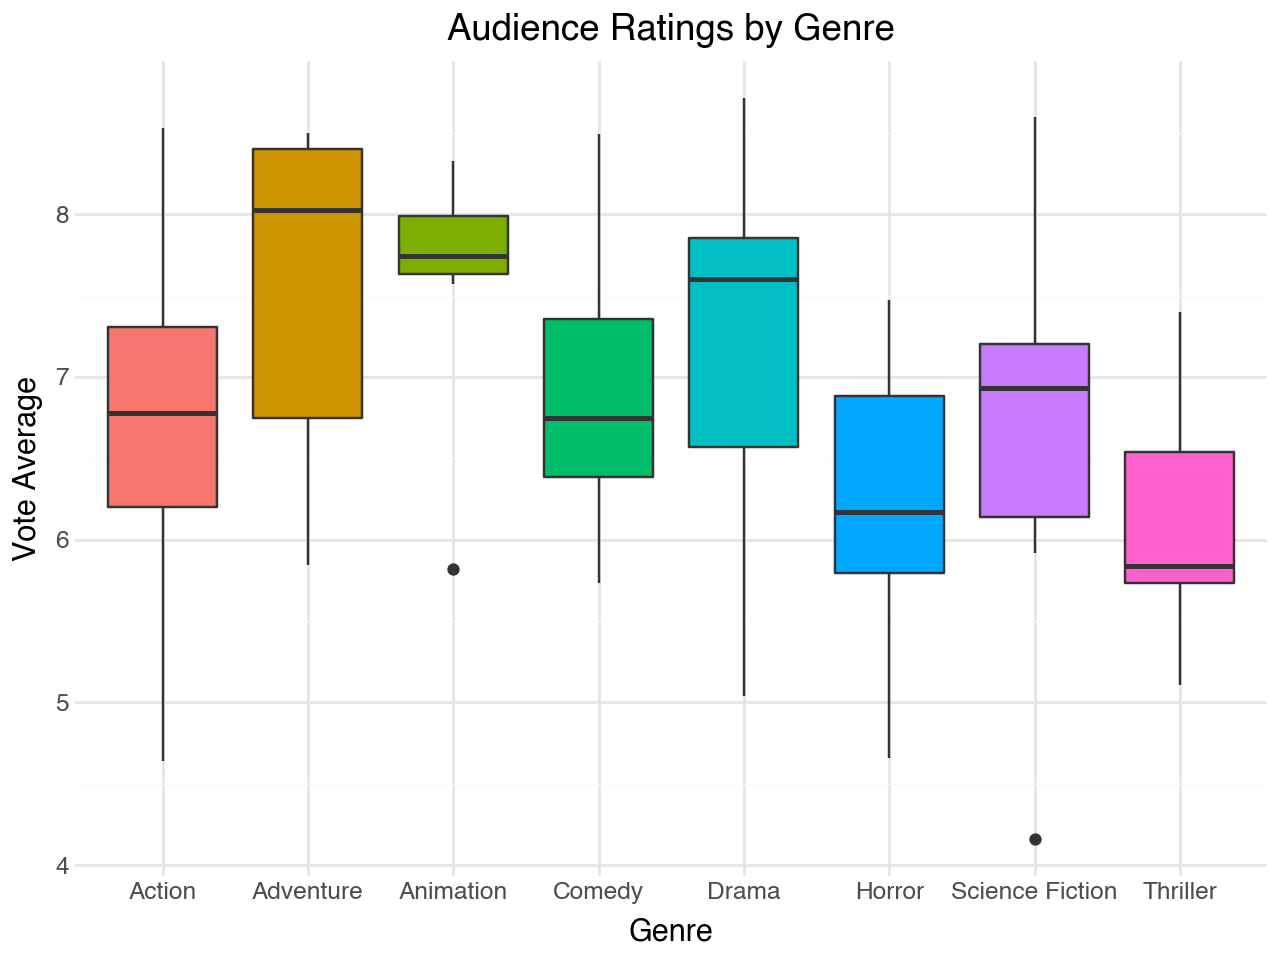

In [11]:
top_genres = (
    df_analysis["primary_genre"]
    .value_counts()
    .head(8)
    .index
)

df_genre = df_analysis[
    df_analysis["primary_genre"].isin(top_genres)
]

p4 = (
    ggplot(df_genre, aes(x="primary_genre", y="vote_average", fill="primary_genre"))
    + geom_boxplot()
    + labs(
        title="Audience Ratings by Genre",
        x="Genre",
        y="Vote Average"
    )
    + theme_minimal()
    + theme(legend_position="none")
)

p4

In [12]:
# ----------------------------
# Budget and revenue analysis
# ----------------------------

df_financial = df_analysis[
    (df_analysis["budget"] > 0) & (df_analysis["revenue"] > 0)
].copy()

print("Movies with financial data:", df_financial.shape[0])

# log transform
df_financial["log_budget"] = np.log10(df_financial["budget"])
df_financial["log_revenue"] = np.log10(df_financial["revenue"])

Movies with financial data: 103


In [13]:
financial_summary = (
    df_financial[["budget","revenue"]]
    .agg(["mean","median","min","max"])
    .round(2)
)

financial_summary

,budget,revenue
mean,8.767149e+07,4.610373e+08
median,6.300000e+07,1.845000e+08
min,2.000000e+00,2.500000e+01
max,4.000000e+08,2.923706e+09


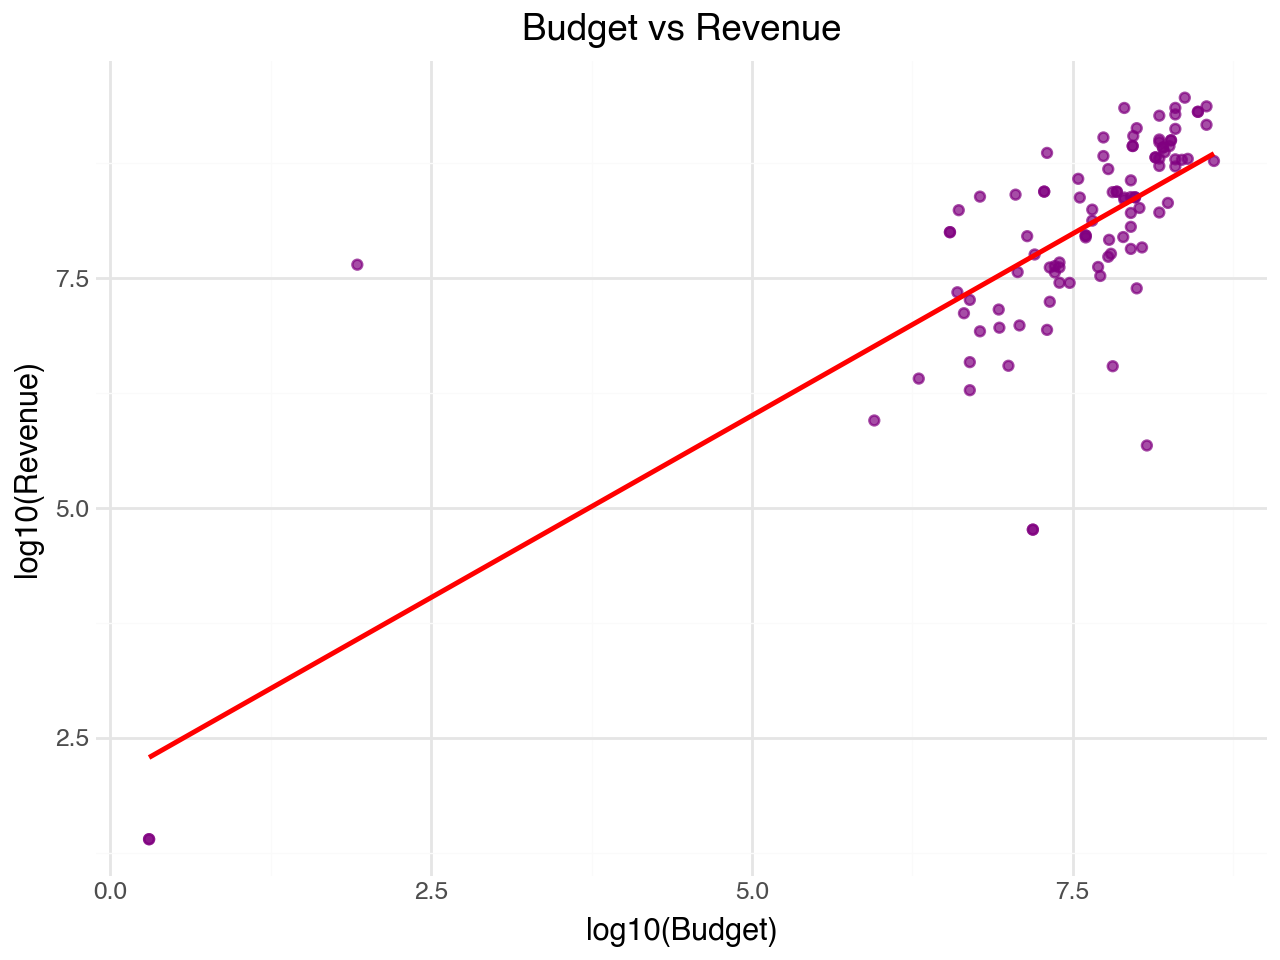

In [14]:
# Budget and Revenue
p5 = (
    ggplot(df_financial, aes(x="log_budget", y="log_revenue"))
    + geom_point(color="purple", alpha=0.7)
    + geom_smooth(method="lm", color="red", se=False)
    + labs(
        title="Budget vs Revenue",
        x="log10(Budget)",
        y="log10(Revenue)"
    )
    + theme_minimal()
)

p5

In [15]:
#  Correlation matrix of key movie variables.
import seaborn as sns
import matplotlib.pyplot as plt

corr_vars = df_analysis[
    ["vote_average","popularity","vote_count","runtime","budget","revenue"]
].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_vars, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Movie Variables")

Text(0.5, 1.0, 'Correlation Between Movie Variables')